## Libraries

In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset from HuggingFace 

In [3]:
from datasets import load_dataset

dataset = load_dataset("databricks/databricks-dolly-15k")

## Convert the dataset to pandas
### making it easy to handle 

In [4]:
df = dataset["train"].to_pandas()

df.head()

,instruction,context,response,category
0,When did Virgin Australia start operating?,"Virgin Australia, the trading name of Virgin A...",Virgin Australia commenced services on 31 Augu...,closed_qa
1,Which is a species of fish? Tope or Rope,,Tope,classification
2,Why can camels survive for long without water?,,Camels use the fat in their humps to keep them...,open_qa
3,"Alice's parents have three daughters: Amy, Jes...",,The name of the third daughter is Alice,open_qa
4,When was Tomoaki Komorida born?,Komorida was born in Kumamoto Prefecture on Ju...,"Tomoaki Komorida was born on July 10,1981.",closed_qa


## EDA

In [9]:
df.shape

(15011, 6)

In [6]:
df.columns

Index(['instruction', 'context', 'response', 'category'], dtype='object')

In [7]:
df["category"].value_counts()

category
open_qa                   3742
general_qa                2191
classification            2136
closed_qa                 1773
brainstorming             1766
information_extraction    1506
summarization             1188
creative_writing           709
Name: count, dtype: int64

In [11]:
# Categories distribution
print("Category counts:")
print(df['category'].value_counts())

Category counts:
category
open_qa                   3742
general_qa                2191
classification            2136
closed_qa                 1773
brainstorming             1766
information_extraction    1506
summarization             1188
creative_writing           709
Name: count, dtype: int64


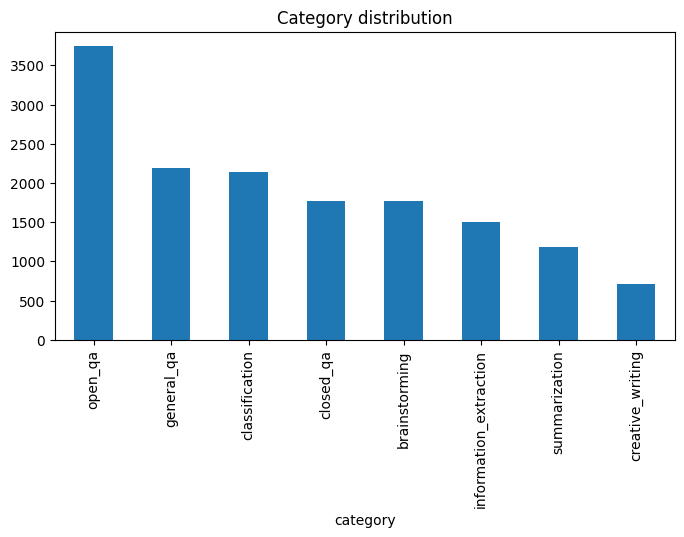

In [6]:
plt.figure(figsize=(8,4))
df["category"].value_counts().plot(kind="bar")
plt.title("Category distribution")
plt.show()

In [12]:
df["instr_len"] = df["instruction"].apply(len)
df["resp_len"] = df["response"].apply(len)

df[["instr_len","resp_len"]].describe()

,instr_len,resp_len
count,15011.000000,15011.000000
mean,71.839384,358.104190
std,134.679885,591.581031
min,4.000000,1.000000
25%,37.000000,78.000000
50%,54.000000,186.000000
75%,81.000000,430.000000
max,11698.000000,26018.000000


In [13]:
df["has_context"] = df["context"].apply(lambda x: len(x) > 0)

df["has_context"].value_counts()

has_context
False    10544
True      4467
Name: count, dtype: int64

## Data Quality Check  

In [9]:
df.sample(5)[["instruction","context","response","category"]]

,instruction,context,response,category
3699,Please give me details about the French submar...,,The French submarine Requin was the lead ship ...,open_qa
7970,Are platypuses mammals or oviparous?,,Platypuses are both mammals (as they raise the...,classification
6040,Who is playing in 2023 women’s NCAA championsh...,,The Iowa Hawkeyes face the LSU Tigers in the W...,general_qa
11829,What is the best way to recover from a shoulde...,,Non surgical interventions include physical th...,general_qa
2591,How does Spark relate to Apache Hadoop?,,Spark is a fast and general processing engine ...,general_qa


In [10]:
df.sort_values("instr_len", ascending=False).head(5)

,instruction,context,response,category,instr_len,resp_len,has_context
10834,"The ""Garbage collection"" log of a JVM is forma...",,1. The log has 47 GC operations over a 36-minu...,general_qa,11698,1065,False
6346,Luka Modrić (Croatian pronunciation: [lûːka mǒ...,Who is Luka Modric?,Luka Modric is a Croatian professional footbal...,closed_qa,3502,419,True
11562,Give me a one line summary of the story below:...,,The Queen of Odisha invites a master stone scu...,general_qa,3278,267,False
10921,Give me a one line summary of the story below:...,,A master sculptor in Odisha is hired by the Ki...,general_qa,3278,250,False
5992,Give me a one line summary of the story below:...,,An Odia sculptor successfully bargains with th...,general_qa,3278,232,False


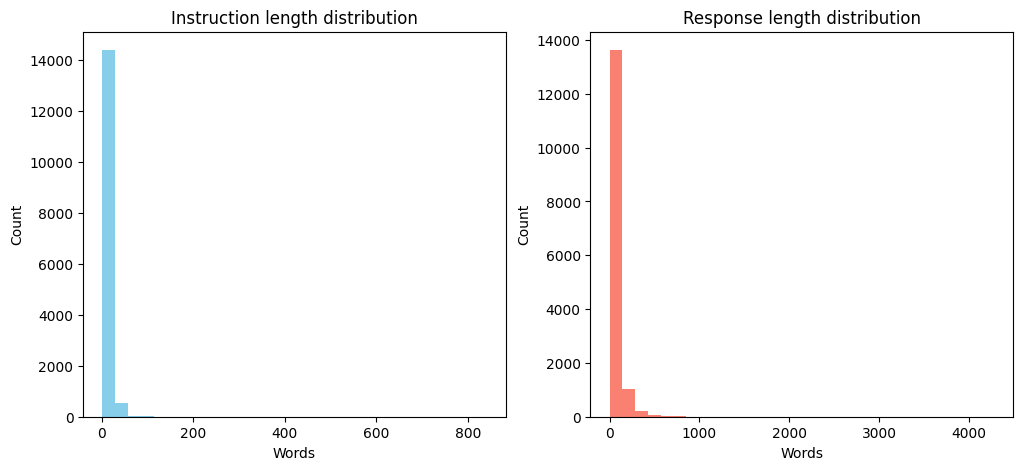

In [16]:
# Visualize instruction & response lengths
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['instr_len'], bins=30, color='skyblue')
plt.title("Instruction length distribution")
plt.xlabel("Words")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(df['resp_len'], bins=30, color='salmon')
plt.title("Response length distribution")
plt.xlabel("Words")
plt.ylabel("Count")

plt.show()

## Light Preprocessing  
### We dont want to lose some info or the structure of the instructions, So we will keep it light 

In [17]:
# Fill empty context with empty string
df['context'] = df['context'].fillna("")

# Strip whitespaces
df['instruction'] = df['instruction'].str.strip()
df['response'] = df['response'].str.strip()
df['category'] = df['category'].str.strip()

# Keep only necessary columns
clean_df = df[['instruction','context','response','category']]

In [18]:
# Split 80/20, stratify by category
from sklearn.model_selection import train_test_split


train_df, test_df = train_test_split(
    clean_df,
    test_size=0.2,
    random_state=42,
    stratify=clean_df['category']
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 12008
Test size: 3003


In [20]:
# Save train
import json


with open("../clean_dolly_train.json", "w") as f:
    for _, row in train_df.iterrows():
        json.dump(row.to_dict(), f)
        f.write("\n")

# Save test
with open("../clean_dolly_test.json", "w") as f:
    for _, row in test_df.iterrows():
        json.dump(row.to_dict(), f)
        f.write("\n")

print("Saved cleaned train/test dataset for project.")

Saved cleaned train/test dataset for project.
